<a href="https://colab.research.google.com/github/alishbazaheer87-cpu/house_price_prediction_model-1-.ipynb/blob/main/house_pricee_prediction_model_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 House Price Prediction Model
**Goal:** Predict house prices with 80%+ R² accuracy.

**Dataset:** Loaded from `House_Price_Prediction_Dataset.csv`

**Features:** Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage → **Price**

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2 — Load the Dataset from CSV

> Place `House_Price_Prediction_Dataset.csv` in the **same folder** as this notebook, then run this cell.
>
> **Google Colab users:** Upload the CSV using the file upload button on the left sidebar first, then run.

In [2]:
import os

CSV_FILE = 'House_Price_Prediction_Dataset.csv'

# ── Google Colab: auto-upload prompt if file not found ──────────────────
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists(CSV_FILE):
    from google.colab import files
    print('📂 Please upload House_Price_Prediction_Dataset.csv')
    uploaded = files.upload()
    CSV_FILE = list(uploaded.keys())[0]

# ── Load ─────────────────────────────────────────────────────────────────
if not os.path.exists(CSV_FILE):
    raise FileNotFoundError(
        f"'{CSV_FILE}' not found.\n"
        "Put the CSV in the same folder as this notebook and re-run."
    )

df = pd.read_csv(CSV_FILE)

# ── Basic validation ──────────────────────────────────────────────────────
required_cols = {'Area','Bedrooms','Bathrooms','Floors','YearBuilt',
                 'Location','Condition','Garage','Price'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f'CSV is missing columns: {missing}')

print(f'✅ Dataset loaded successfully!')
print(f'   Shape : {df.shape}')
print(f'\nPrice Statistics:')
print(df['Price'].describe())
print('\nFirst 5 rows:')
df.head()

📂 Please upload House_Price_Prediction_Dataset.csv


Saving House_Price_Prediction_Dataset (1).csv to House_Price_Prediction_Dataset (1).csv
✅ Dataset loaded successfully!
   Shape : (2000, 10)

Price Statistics:
count      2000.000000
mean     510229.458500
std      169311.144341
min       99814.000000
25%      371350.000000
50%      514555.500000
75%      644793.500000
max      902272.000000
Name: Price, dtype: float64

First 5 rows:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,481101
1,2,4272,5,4,3,1958,Downtown,Excellent,No,801892
2,3,3592,2,2,3,1938,Downtown,Good,No,628870
3,4,966,4,2,2,1902,Suburban,Fair,Yes,273210
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,793095


## Step 3 — Visualize the Data

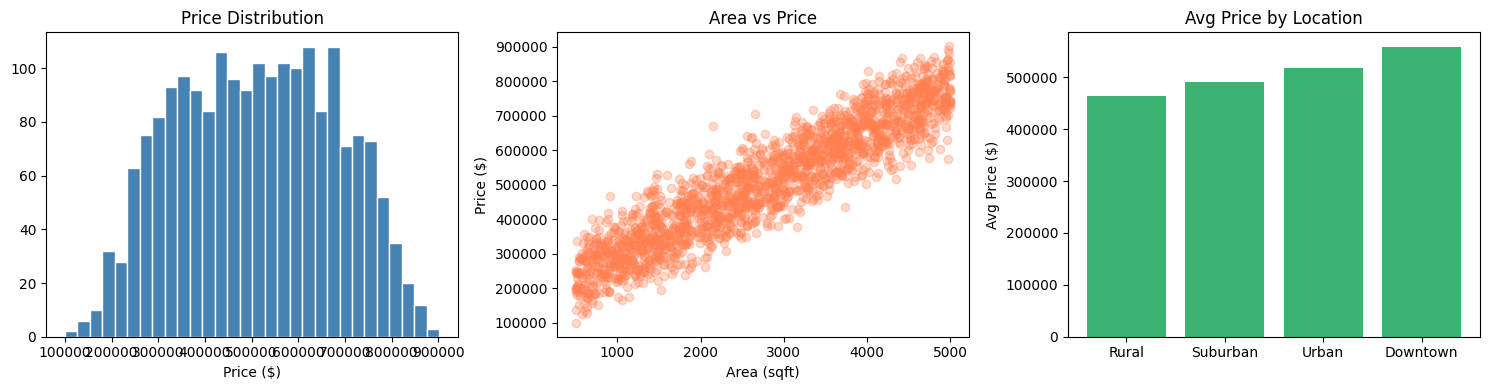

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($)')

axes[1].scatter(df['Area'], df['Price'], alpha=0.3, color='coral')
axes[1].set_title('Area vs Price')
axes[1].set_xlabel('Area (sqft)')
axes[1].set_ylabel('Price ($)')

avg_by_loc = df.groupby('Location')['Price'].mean().sort_values()
axes[2].bar(avg_by_loc.index, avg_by_loc.values, color='mediumseagreen')
axes[2].set_title('Avg Price by Location')
axes[2].set_ylabel('Avg Price ($)')

plt.tight_layout()
plt.show()

## Step 4 — Preprocessing: Ordinal Encoding

We use `OrdinalEncoder` with the **correct meaningful order** for each categorical column.
This preserves the ranking (e.g. Poor < Fair < Good < Excellent) which helps tree-based models split correctly.

In [4]:
# Drop Id column if present
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

encoders = {
    'Condition': OrdinalEncoder(categories=[['Poor', 'Fair', 'Good', 'Excellent']]),
    'Garage':    OrdinalEncoder(categories=[['No', 'Yes']]),
    'Location':  OrdinalEncoder(categories=[['Rural', 'Suburban', 'Urban', 'Downtown']]),
}

for col, enc in encoders.items():
    df[col] = enc.fit_transform(df[[col]])
    print(f'{col} encoded ✅')

print('\nData after encoding:')
df.head()

Condition encoded ✅
Garage encoded ✅
Location encoded ✅

Data after encoding:


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,3.0,3.0,0.0,481101
1,4272,5,4,3,1958,3.0,3.0,0.0,801892
2,3592,2,2,3,1938,3.0,2.0,0.0,628870
3,966,4,2,2,1902,1.0,1.0,1.0,273210
4,4926,1,4,2,1975,3.0,1.0,1.0,793095


## Step 5 — Feature Engineering

We create **7 new derived features** that help the model capture relationships better.

In [5]:
df['HouseAge']       = 2024 - df['YearBuilt']
df['TotalRooms']     = df['Bedrooms'] + df['Bathrooms']
df['AreaPerRoom']    = df['Area'] / (df['TotalRooms'] + 1)
df['AreaPerBedroom'] = df['Area'] / (df['Bedrooms'] + 1)
df['IsNewHouse']     = (df['HouseAge'] < 15).astype(int)
df['LuxuryScore']    = df['Location'] * df['Condition']
df['SpaceScore']     = df['Area'] * df['Floors']
df['QualityAge']     = df['Condition'] / (df['HouseAge'] + 1)

df = df.drop(columns=['YearBuilt'])  # replaced by HouseAge

print(f'Total features: {df.shape[1] - 1}')
print('Features:', list(df.drop(columns=['Price']).columns))

Total features: 15
Features: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Location', 'Condition', 'Garage', 'HouseAge', 'TotalRooms', 'AreaPerRoom', 'AreaPerBedroom', 'IsNewHouse', 'LuxuryScore', 'SpaceScore', 'QualityAge']


## Step 6 — Correlation Heatmap

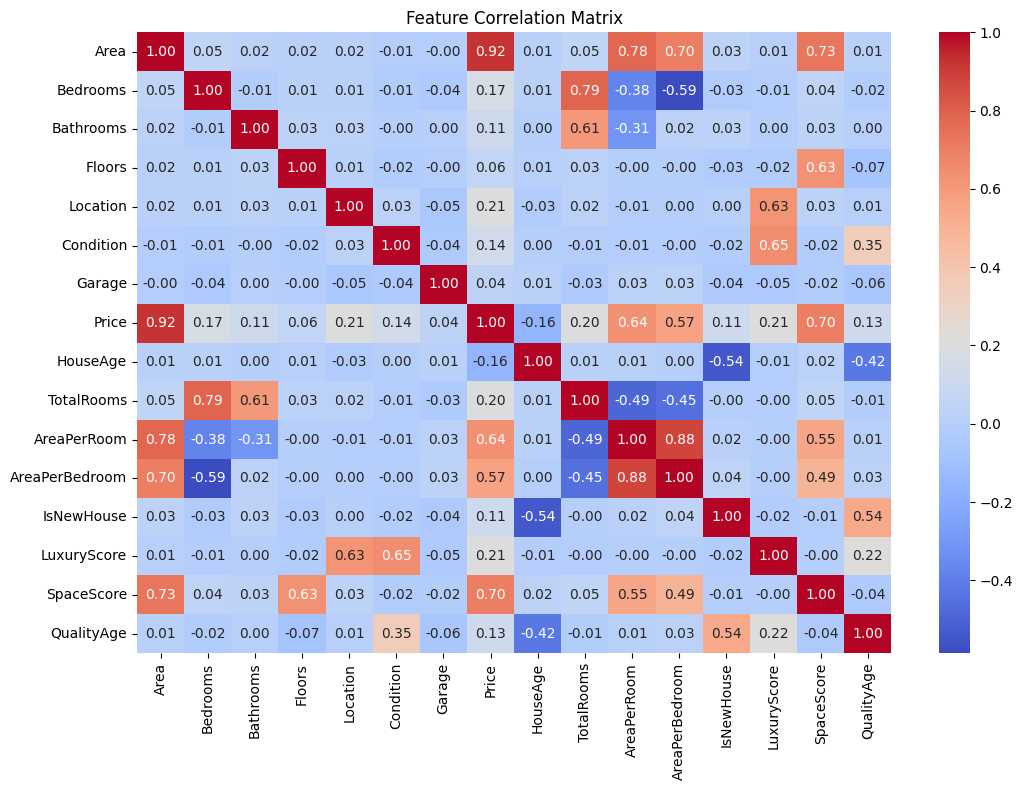

In [6]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Step 7 — Train / Test Split

In [7]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Training samples : 1600
Testing samples  : 400


## Step 8 — Build Stacking Ensemble

Three strong base models feed into a Ridge meta-learner:
- **Random Forest** — low variance, good baseline
- **Gradient Boosting** — captures complex patterns
- **Extra Trees** — faster, adds diversity
- **Ridge** — meta-learner that combines all three predictions optimally

In [8]:
rf = RandomForestRegressor(
    n_estimators=300, max_features='sqrt',
    random_state=42, n_jobs=-1
)
gb = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=5, subsample=0.8, random_state=42
)
et = ExtraTreesRegressor(
    n_estimators=300, random_state=42, n_jobs=-1
)

model = StackingRegressor(
    estimators=[('rf', rf), ('gb', gb), ('et', et)],
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)

print('🚀 Training Stacking Ensemble...')
model.fit(X_train, y_train)
print('✅ Done!')

🚀 Training Stacking Ensemble...
✅ Done!


## Step 9 — Evaluate the Model

In [9]:
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('=' * 45)
print(f'  R² Score   : {r2:.4f}  ({r2*100:.2f}%)')
print(f'  MAE        : ${mae:,.0f}')
print(f'  RMSE       : ${rmse:,.0f}')
print('=' * 45)

if r2 >= 0.80:
    print(f'\n🎉 Target achieved! R² is above 80%!')
else:
    print(f'\n⚠️ Below 80%.')

  R² Score   : 0.9571  (95.71%)
  MAE        : $27,472
  RMSE       : $34,888

🎉 Target achieved! R² is above 80%!


## Step 10 — Cross-Validation

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print('CV R² Scores:', np.round(cv_scores, 4))
print(f'Mean CV R²  : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'Std Dev     : {cv_scores.std():.4f}')

CV R² Scores: [0.9577 0.9586 0.9601 0.9524 0.9635]
Mean CV R²  : 0.9585 (95.85%)
Std Dev     : 0.0036


## Step 11 — Actual vs Predicted Plot

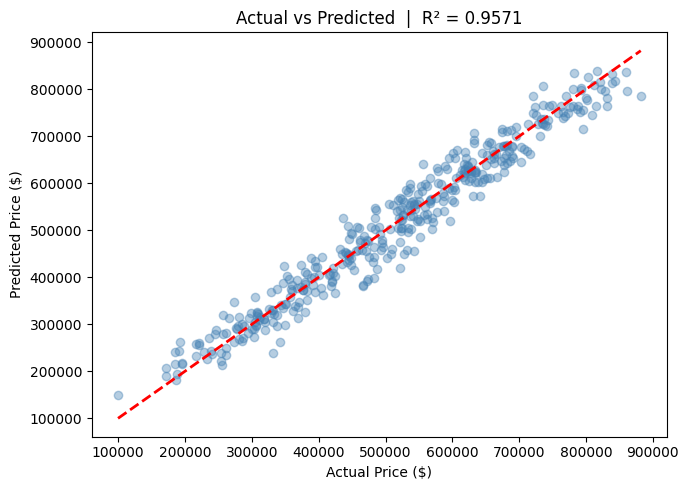

In [11]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'Actual vs Predicted  |  R² = {r2:.4f}')
plt.tight_layout()
plt.show()

## Step 12 — Feature Importance

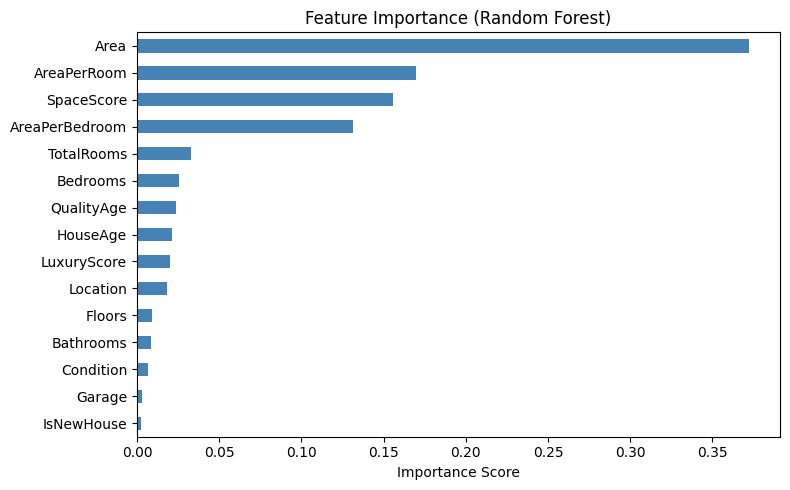

In [12]:
rf_fitted = model.estimators_[0]
importances = pd.Series(rf_fitted.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 13 — 🏠 Interactive House Price Predictor

In [13]:
def get_int(prompt, min_val, max_val):
    while True:
        try:
            val = int(input(prompt))
            if min_val <= val <= max_val:
                return val
            print(f'  ⚠️  Please enter a value between {min_val} and {max_val}.')
        except ValueError:
            print('  ⚠️  Invalid input. Please enter a whole number.')

def get_choice(prompt, options):
    print(prompt)
    for i, opt in enumerate(options, 1):
        print(f'  {i}. {opt}')
    while True:
        try:
            idx = int(input('  Enter number: '))
            if 1 <= idx <= len(options):
                return options[idx - 1]
            print(f'  ⚠️  Please enter a number between 1 and {len(options)}.')
        except ValueError:
            print('  ⚠️  Invalid input. Please enter a number.')

print('=' * 50)
print('   🏠  HOUSE PRICE PREDICTOR — Enter Details')
print('=' * 50)

area_in       = get_int('\n📐 Area (sqft) [500 – 5000]: ', 500, 5000)
bedrooms_in   = get_int('🛏️  Bedrooms [1 – 5]: ', 1, 5)
bathrooms_in  = get_int('🚿 Bathrooms [1 – 4]: ', 1, 4)
floors_in     = get_int('🏗️  Floors [1 – 3]: ', 1, 3)
year_built_in = get_int('📅 Year Built [1900 – 2024]: ', 1900, 2024)

location_in  = get_choice('\n📍 Location:', ['Rural', 'Suburban', 'Urban', 'Downtown'])
condition_in = get_choice('\n🔧 Condition:', ['Poor', 'Fair', 'Good', 'Excellent'])
garage_in    = get_choice('\n🚗 Garage:', ['No', 'Yes'])

# Encode
location_enc  = {'Rural': 0, 'Suburban': 1, 'Urban': 2, 'Downtown': 3}[location_in]
condition_enc = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}[condition_in]
garage_enc    = {'No': 0, 'Yes': 1}[garage_in]

# Engineered features
house_age        = 2024 - year_built_in
total_rooms      = bedrooms_in + bathrooms_in
area_per_room    = area_in / (total_rooms + 1)
area_per_bedroom = area_in / (bedrooms_in + 1)
is_new_house     = int(house_age < 15)
luxury_score     = location_enc * condition_enc
space_score      = area_in * floors_in
quality_age      = condition_enc / (house_age + 1)

new_house = pd.DataFrame([{
    'Area'          : area_in,
    'Bedrooms'      : bedrooms_in,
    'Bathrooms'     : bathrooms_in,
    'Floors'        : floors_in,
    'Location'      : location_enc,
    'Condition'     : condition_enc,
    'Garage'        : garage_enc,
    'HouseAge'      : house_age,
    'TotalRooms'    : total_rooms,
    'AreaPerRoom'   : area_per_room,
    'AreaPerBedroom': area_per_bedroom,
    'IsNewHouse'    : is_new_house,
    'LuxuryScore'   : luxury_score,
    'SpaceScore'    : space_score,
    'QualityAge'    : quality_age,
}])[X.columns]

predicted_price = model.predict(new_house)[0]

print('\n' + '=' * 50)
print('   📋  HOUSE SUMMARY')
print('=' * 50)
print(f'  Area        : {area_in:,} sqft')
print(f'  Bedrooms    : {bedrooms_in}')
print(f'  Bathrooms   : {bathrooms_in}')
print(f'  Floors      : {floors_in}')
print(f'  Year Built  : {year_built_in}  (Age: {house_age} yrs)')
print(f'  Location    : {location_in}')
print(f'  Condition   : {condition_in}')
print(f'  Garage      : {garage_in}')
print('─' * 50)
print(f'  💰 Predicted Price : ${predicted_price:,.0f}')
print('=' * 50)

   🏠  HOUSE PRICE PREDICTOR — Enter Details

📐 Area (sqft) [500 – 5000]: 465
  ⚠️  Please enter a value between 500 and 5000.

📐 Area (sqft) [500 – 5000]: 477
  ⚠️  Please enter a value between 500 and 5000.

📐 Area (sqft) [500 – 5000]: 577
🛏️  Bedrooms [1 – 5]: 533
  ⚠️  Please enter a value between 1 and 5.
🛏️  Bedrooms [1 – 5]: 4
🚿 Bathrooms [1 – 4]: 4
🏗️  Floors [1 – 3]: 3
📅 Year Built [1900 – 2024]: 2022

📍 Location:
  1. Rural
  2. Suburban
  3. Urban
  4. Downtown
  Enter number: 3

🔧 Condition:
  1. Poor
  2. Fair
  3. Good
  4. Excellent
  Enter number: 3

🚗 Garage:
  1. No
  2. Yes
  Enter number: 2

   📋  HOUSE SUMMARY
  Area        : 577 sqft
  Bedrooms    : 4
  Bathrooms   : 4
  Floors      : 3
  Year Built  : 2022  (Age: 2 yrs)
  Location    : Urban
  Condition   : Good
  Garage      : Yes
──────────────────────────────────────────────────
  💰 Predicted Price : $353,697
